5、拓展：强制使用工具
5.1 tool_choice参数说明
bind_tools 可以传递参数
tool_choice ，用于控制是否强制使用工具。
该字段最终会作为
payload 的
tool_choice 字段传递给模型，OpenAI和Deepseek的官方API服务对于
tool_choice 的取值做了相同的规定。

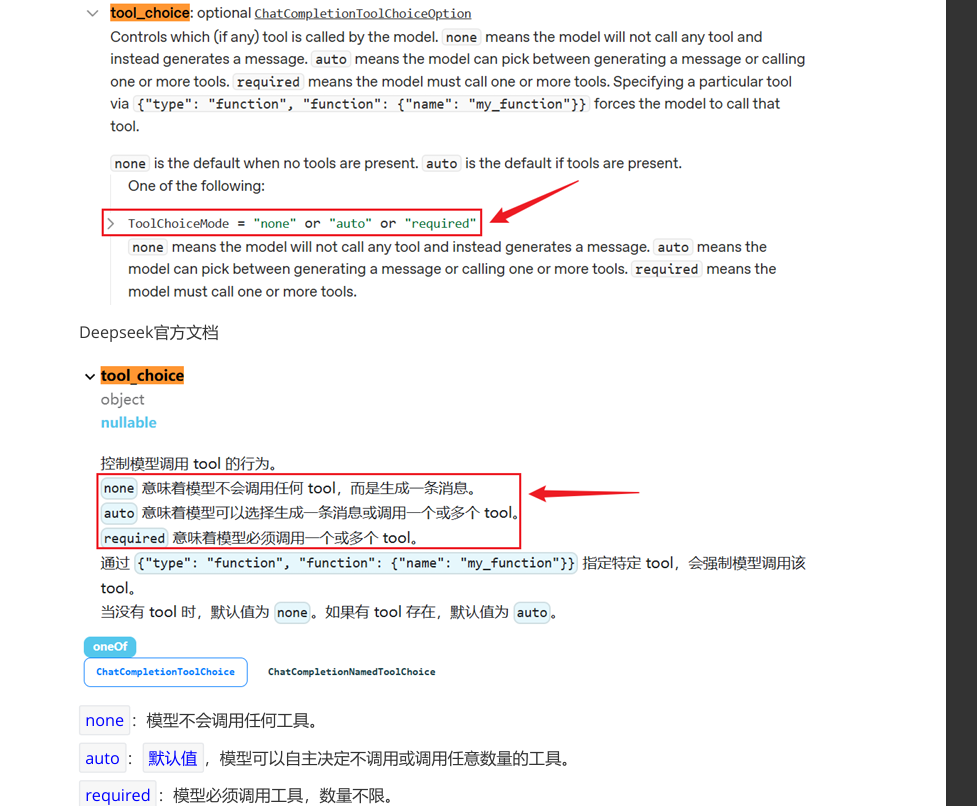

5.2 none值举例

In [5]:
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL
)


@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取当日天气

    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'


model_with_tools = model.bind_tools([get_weather], tool_choice="none")
messages = [
    HumanMessage("今天北京天气如何？别瞎编")
]
response = model_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

抱歉，我无法提供实时的天气信息。建议你打开联网搜索功能查询，或者直接查看手机上的天气App或中国天气网等官方渠道，这样能获取到最准确的北京今天天气情况。


强制调用指定的工具

In [ ]:
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL
)


@tool(parse_docstring=True)
def get_weather1(city: str) -> str:
    """
    获取当日天气
    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'


@tool(parse_docstring=True)
def get_weather2(city: str) -> str:
    """
    获取当日天气
    Args:
        city: 城市名称
    """
    return f'{city}当天晴朗'


model_with_tools = model.bind_tools([get_weather1, get_weather2], tool_choice="get_weather1")
messages = [
    HumanMessage("今天北京天气如何？别瞎编")
]
response = model_with_tools.invoke(messages)
response.pretty_print()